11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


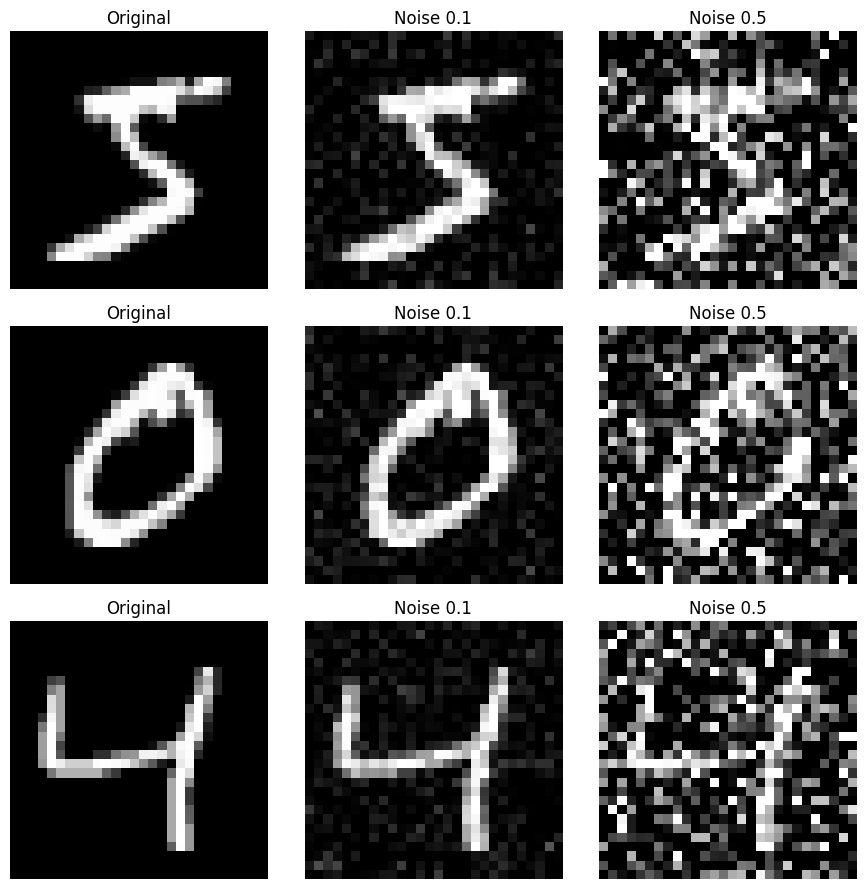

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# 1. Load and preprocess MNIST
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

# Reshape for CNN input (Samples, Height, Width, Channels)
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# 2. Generate noisy versions
noise_factor_low = 0.1
noise_factor_high = 0.5

# Adding Gaussian noise
x_train_noisy_low = x_train + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy_low = x_test + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_test_noisy_high = x_test + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# 3. Clip pixel values to [0, 1] range
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)
x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)

# 4. Visualize in a 3 x 3 grid
n = 3 # number of images to show
plt.figure(figsize=(9, 9))

for i in range(n):
    # Original image - Column 1
    ax = plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Low noise image - Column 2
    ax = plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.1")
    plt.axis('off')

    # High noise image - Column 3
    ax = plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.5")
    plt.axis('off')

plt.tight_layout()
plt.show()

#Step2 BUilding convlutional denoisig Autoencoder model



In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
#Encoder
def build_encoder(input_shape=(28, 28, 1)):
  """
Builds the encoder part of the convolutional autoencoder.
Parameters:
input_shape (tuple): Shape of the input image. Default is (28, 28, 1) for MNIST.
Returns:
input_img (Keras Input): Input layer of the model.
encoded (Keras Tensor): Encoded representation after convolution and pooling.
"""
  input_img = Input(shape=input_shape, name="input")
  x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
  x = MaxPooling2D((2, 2), padding='same')(x)
  x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
  encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)
  return input_img, encoded

In [ ]:
#Decoder :building Decoder
def build_decoder(encoded_input):
  """
Builds the decoder part of the convolutional autoencoder.
Parameters:
encoded_input (Keras Tensor): The output from the encoder.

Returns:
decoded (Keras Tensor): The reconstructed output after upsampling and
convolution.
"""
  x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
  x = UpSampling2D((2, 2))(x)
  x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
  x = UpSampling2D((2, 2))(x)
  decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)
  return decoded

In [ ]:
#Complete Autoemcoder
def build_autoencoder():
  """
Constructs and compiles the full convolutional autoencoder by connecting encoder and
decoder.
Returns:
autoencoder (Keras Model): Compiled autoencoder model.
"""
  input_img, encoded_output = build_encoder()
  decoded_output = build_decoder(encoded_output)
  autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
  #use binary crossentrory eventho no binary each noise ko lagi model le noise nagare orifinal matra image recreaet hos
  autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
  return autoencoder

In [ ]:
#Compiling mOdel
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 201s 422ms/step - loss: 0.1504 - val_loss: 0.1109
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 203s 423ms/step - loss: 0.1085 - val_loss: 0.1039
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 200s 419ms/step - loss: 0.1035 - val_loss: 0.1008
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 195s 416ms/step - loss: 0.1009 - val_loss: 0.0992
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 204s 421ms/step - loss: 0.0993 - val_loss: 0.0980
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 194s 414ms/step - loss: 0.0983 - val_loss: 0.0971
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 194s 413ms/step - loss: 0.0975 - val_loss: 0.0962
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 193s 412ms/step - loss: 0.0967 - val_loss: 0.0960
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 199s 425ms/step - loss: 0.0961 - val_loss: 0.0952
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 194s 413ms/step - loss: 0.0956 - val_loss: 0.0948


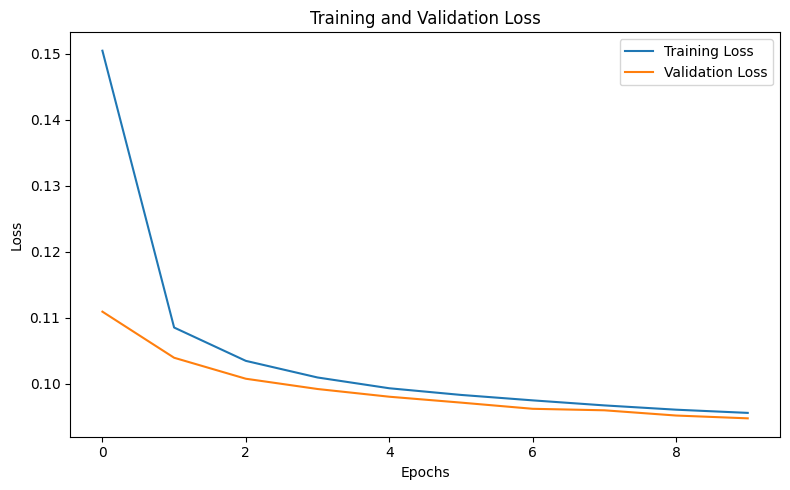

In [ ]:
# Step 3: Train the autoencoder
# Build the autoencoder from previous steps
autoencoder = build_autoencoder()

# Train with noisy input and clean target
history = autoencoder.fit(
    x_train_noisy_high, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy_high, x_test)
)

# Plot Training and Validation Loss
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step


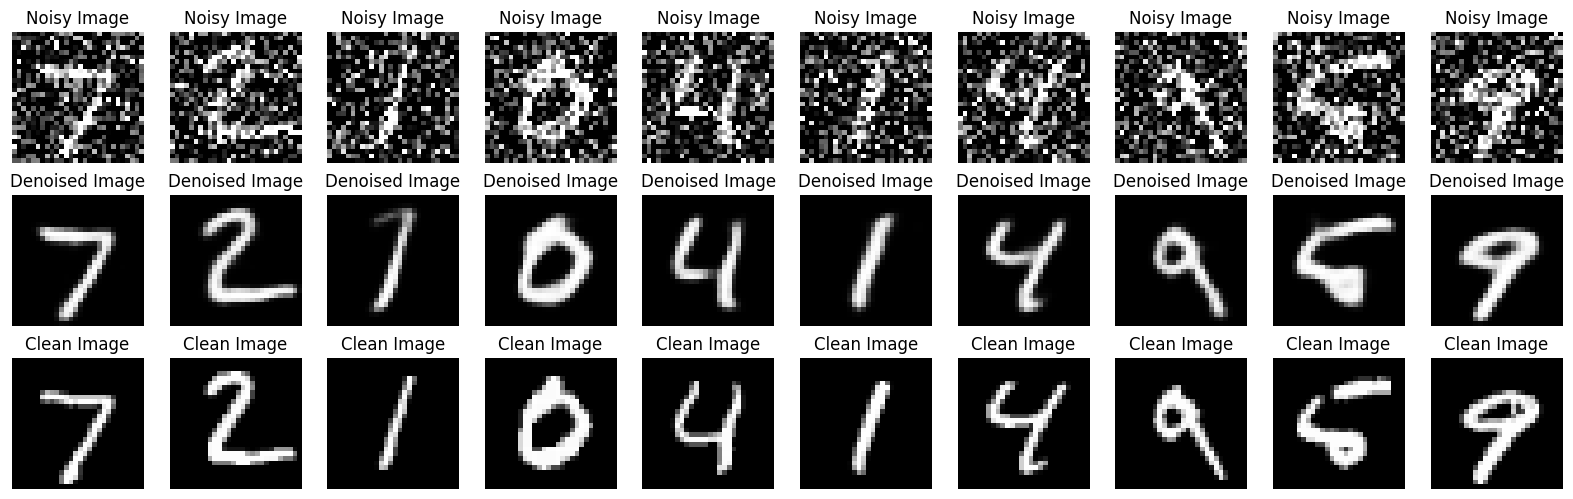

In [ ]:
#Step4 Evaluating the Autoencoder
# Predict the denoised images from noisy test images
denoised_images = autoencoder.predict(x_test_noisy_high)
# Function to display images
def plot_images(noisy_images, denoised_images, clean_images, n=10):
  plt.figure(figsize=(20, 6))
  for i in range(n):
# Plot noisy images
    plt.subplot(3, n, i + 1)
    plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy Image")
    plt.axis('off')
# Plot denoised images
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised Image")
    plt.axis('off')
# Plot clean images
    plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
    plt.title("Clean Image")
    plt.axis('off')
  plt.show()
# Display the first 10 images
plot_images(x_test_noisy_high, denoised_images, x_test, n=10)

 **Exercise: Build a Denoising Convolutional Autoencoder
Dataset: Devnagari Handwritten Digit Dataset**

In [ ]:
# ── Core scientific / deep-learning libraries ──────────────────────────────
import os                          # file-system utilities
import numpy as np                 # numerical arrays
import matplotlib.pyplot as plt    # plotting
from PIL import Image              # image loading (as required by the task)
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

# Reproducibility: fix random seeds so results are the same every run
np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
import os
import zipfile
import shutil
from google.colab import drive

drive.mount('/content/drive')

ZIP_PATH   = "/content/drive/MyDrive/AI And ML/Week7/DevanagariHandwrittenDigitDataset.zip"
EXTRACT_TO = "dataset/"


os.makedirs(EXTRACT_TO)
print("Extracting …")
with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_TO)
print("Done!")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting …
Done!


In [ ]:
# ── 1-A  Configuration ─────────────────────────────────────────────────────
DATASET_ROOT = 'dataset/DevanagariHandwrittenDigitDataset'
IMG_SIZE     = 32
MAX_IMAGES   = 5000

# ── 1-B  Load images with PIL
def load_devnagari_images(root, split='Train', max_images=None):
    images = []
    split_dir = os.path.join(root, split)

    # CHecking if path is wrong
    if not os.path.exists(split_dir):
        raise FileNotFoundError(f"Could not find: {split_dir}\n"
                                f"Contents of dataset/: {os.listdir('dataset/')}")

    for class_folder in sorted(os.listdir(split_dir)):
        class_path = os.path.join(split_dir, class_folder)
        if not os.path.isdir(class_path):
            continue

        for fname in os.listdir(class_path):
            if not fname.lower().endswith('.png'):
                continue
            img_path = os.path.join(class_path, fname)
            img = Image.open(img_path).convert('L')
            img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
            images.append(np.array(img, dtype=np.float32))

            if max_images and len(images) >= max_images:
                return np.array(images)

    return np.array(images)

raw_images = load_devnagari_images(DATASET_ROOT, split='Train', max_images=MAX_IMAGES)
print(f'Loaded {len(raw_images)} images, shape per image: {raw_images.shape[1:]}')

Loaded 5000 images, shape per image: (32, 32)


In [ ]:
#NOrmalizating to 0,1
images_norm = raw_images / 255.0
#Adding channel dimension as req from keras conv2d as it expect shape is (batch,height,width n chanel) n np.newaxis add axis at end
images_norm = images_norm[..., np.newaxis]
print('After reshape:', images_norm.shape)

#Train/Validation split
x_train, x_val = train_test_split(images_norm, test_size = 0.2, random_state = 42)
print(f"Train: {x_train.shape} Val:{x_val.shape}")

After reshape: (5000, 32, 32, 1)
Train: (4000, 32, 32, 1) Val:(1000, 32, 32, 1)


In [ ]:
#Adding noiese since autoencoder will receive nosy image as inut and learn output
NOISE_FACTOR = 0.3
def add_gaussian_noise(data, noise_factor=0.3):
    """
    Add zero-mean Gaussian noise with std = noise_factor.
    np.random.normal(0, noise_factor, data.shape) samples from N(0, noise_factor).
    np.clip ensures every pixel stays within [0, 1] after adding noise.
    """
    noise  = np.random.normal(loc=0.0, scale=noise_factor, size=data.shape)
    noisy  = data + noise
    return np.clip(noisy, 0.0, 1.0).astype(np.float32)

x_train_noisy = add_gaussian_noise(x_train, NOISE_FACTOR)
x_val_noisy   = add_gaussian_noise(x_val,   NOISE_FACTOR)

print('Noisy train shape:', x_train_noisy.shape)
print('Pixel range  min:', x_train_noisy.min(), ' max:', x_train_noisy.max())


Noisy train shape: (4000, 32, 32, 1)
Pixel range  min: 0.0  max: 1.0


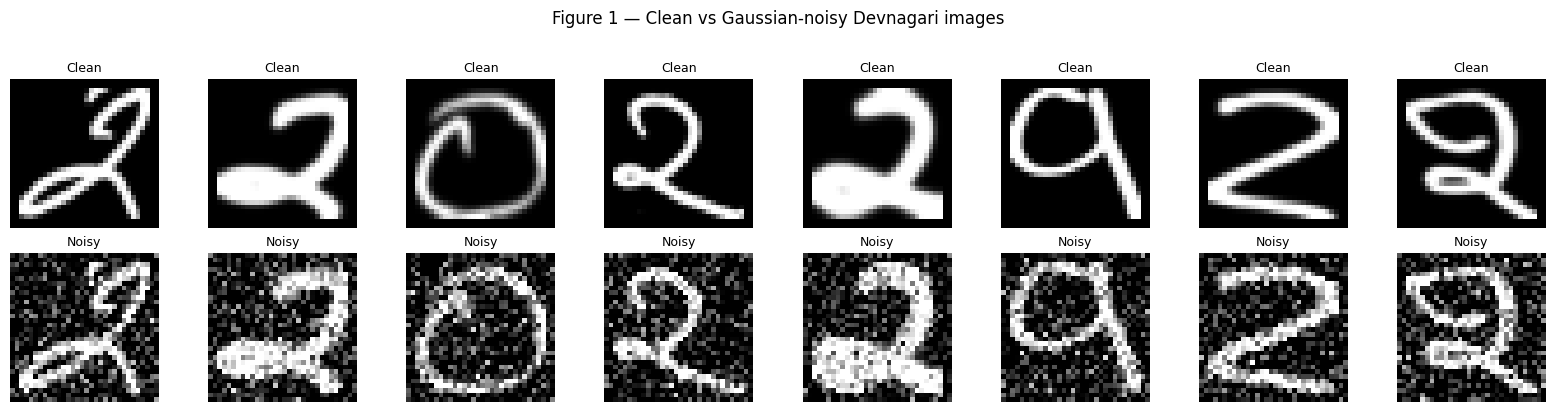

In [ ]:
#Visualising sample images clean n nisy
n = 8
fig, axes = plt.subplots(2,n,figsize=(16,4))
for i in range(n):
    # Top row: clean originals
    axes[0, i].imshow(x_train[i].squeeze(), cmap='gray')
    axes[0, i].set_title('Clean', fontsize=9)
    axes[0, i].axis('off')

    # Bottom row: noisy versions
    axes[1, i].imshow(x_train_noisy[i].squeeze(), cmap='gray')
    axes[1, i].set_title('Noisy', fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('Figure 1 — Clean vs Gaussian-noisy Devnagari images', y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
#Denoising COnvolutional Autoencder
def build_autoencoder(input_shape=(32, 32, 1)):
    """
    Builds and returns a compiled Keras convolutional autoencoder.
    """

    # ── INPUT ─────────────────────────────────────────────────────────────
    # keras.Input defines the shape of one sample (without the batch dimension).
    inputs = keras.Input(shape=input_shape, name='encoder_input')

 #encode

    # Layer 1 — Conv2D(32 filters, 3×3 kernel, same padding, ReLU)
    # 'same' padding keeps spatial size unchanged after convolution (32×32 → 32×32).
    # 32 filters = the network learns 32 different low-level feature maps.
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      name='enc_conv1')(inputs)

    # MaxPooling(2×2): halves spatial size  32×32 → 16×16.
    # Keeps only the strongest activation in each 2×2 neighbourhood.
    # This is the "compression" step — forces the encoder to generalise.
    x = layers.MaxPooling2D((2, 2), padding='same', name='enc_pool1')(x)

    # Layer 2 — 64 filters, deeper features (combinations of Layer-1 features)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                      name='enc_conv2')(x)
    # 16×16 → 8×8
    x = layers.MaxPooling2D((2, 2), padding='same', name='enc_pool2')(x)

    # Layer 3 — 128 filters, high-level stroke structure
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                      name='enc_conv3')(x)
    # 8×8 → 4×4
    x = layers.MaxPooling2D((2, 2), padding='same', name='enc_pool3')(x)


    encoded = layers.Conv2D(256, (3, 3), activation='relu', padding='same',
                            name='bottleneck')(x)


    # Layer 5 — Conv2DTranspose(128, stride=2)
    # Conv2DTranspose is the learnable inverse of Conv2D + MaxPool.
    # strides=(2,2) doubles the spatial resolution: 4×4 → 8×8.
    # 'same' padding ensures exact doubling.
    x = layers.Conv2DTranspose(128, (3, 3), strides=(2, 2), activation='relu',
                               padding='same', name='dec_conv1')(encoded)

    # Layer 6 — 64 filters, 8×8 → 16×16
    x = layers.Conv2DTranspose(64, (3, 3), strides=(2, 2), activation='relu',
                               padding='same', name='dec_conv2')(x)

    # Layer 7 — 32 filters, 16×16 → 32×32  (back to original spatial size)
    x = layers.Conv2DTranspose(32, (3, 3), strides=(2, 2), activation='relu',
                               padding='same', name='dec_conv3')(x)

    # Layer 8 (OUTPUT) — 1 filter (grayscale), Sigmoid activation.
    # Sigmoid maps any real value to (0,1), matching pixel range [0,1].
    # No strides here — spatial size stays 32×32.
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid',
                            padding='same', name='decoder_output')(x)

    # ── Assemble the model
    autoencoder = Model(inputs, decoded, name='denoising_autoencoder')

    # ── Compile
    # Optimizer: Adam — adaptive learning rate, good default for most tasks.
    # Loss: binary_crossentropy treats each pixel as a Bernoulli variable,
    #       well-suited when output is in [0,1]; MSE is also common.
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

    return autoencoder


autoencoder = build_autoencoder()
autoencoder.summary()

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling2D)        │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv3 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool3 (MaxPooling2D)        │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Conv2D)             │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv2DTranspose)     │ (None, 8, 8, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv2DTranspose)     │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv3 (Conv2DTranspose)     │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Conv2D)         │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 775,425 (2.96 MB)

 Trainable params: 775,425 (2.96 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Training the Denoising Autoencdoer
# EarlyStopping: stop training if val_loss does not improve for 5 epochs.
# This prevents overfitting and saves time.
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',   # metric to watch
    patience=5,           # tolerate 5 epochs of no improvement
    restore_best_weights=True   # revert to the epoch with lowest val_loss
)

# ReduceLROnPlateau: halve learning rate if val_loss stalls for 3 epochs.
# Helps escape flat regions of the loss landscape.
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

# ── Training ──────────────────────────────────────────────────────────────
# Input  = noisy images  (x_train_noisy)   ← what the model SEES
# Target = clean images  (x_train)         ← what the model must PRODUCE
# batch_size=128: process 128 images per gradient update (good GPU utilisation)
# epochs=50: upper limit; EarlyStopping will interrupt sooner if appropriate
history = autoencoder.fit(
    x_train_noisy, x_train,           # noisy → clean
    epochs=50,
    batch_size=128,
    shuffle=True,                      # shuffle training data each epoch
    validation_data=(x_val_noisy, x_val),  # monitor on held-out data
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - loss: 0.5643 - val_loss: 0.4589 - learning_rate: 0.0010
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - loss: 0.4001 - val_loss: 0.3113 - learning_rate: 0.0010
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - loss: 0.2701 - val_loss: 0.2372 - learning_rate: 0.0010
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - loss: 0.2179 - val_loss: 0.2069 - learning_rate: 0.0010
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - loss: 0.1947 - val_loss: 0.1883 - learning_rate: 0.0010
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - loss: 0.1813 - val_loss: 0.1830 - learning_rate: 0.0010
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - loss: 0.1733 - val_loss: 0.1708 - learning_rate: 0.0010
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - loss: 0.1674 - val_loss: 0.1663 - learning_rate: 0.0010
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - loss: 0.1644 - val_loss: 0.1643 - learning_rate: 0.0010
Epoch 10/50
32/32 ━━━━━━━━━━

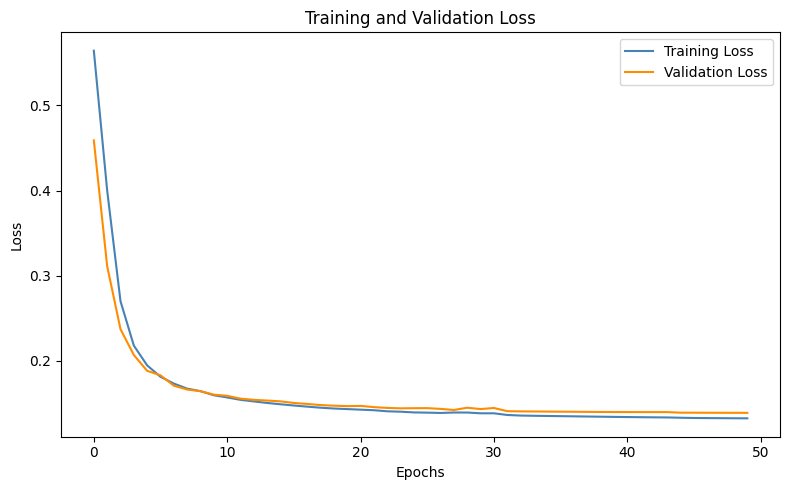

In [ ]:
#PLoting train and val
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'],     label='Training Loss',   color='steelblue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='darkorange')

plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step
Denoised output shape: (1000, 32, 32, 1)


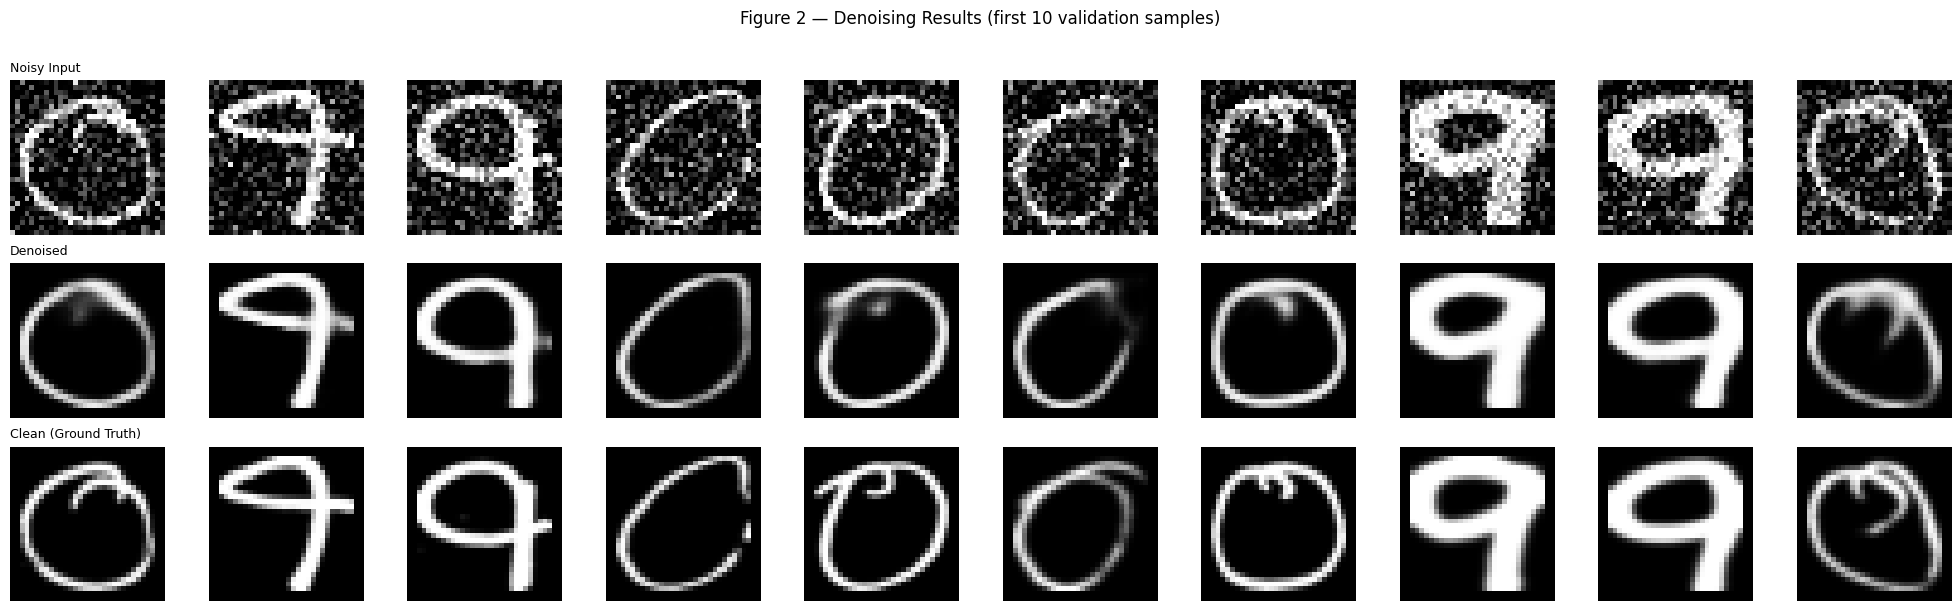

In [ ]:
#Evaluating and visalulizing the reuslt
# ── Predict denoised images on the validation set ─────────────────────────
# autoencoder.predict() runs forward-pass in batches; returns numpy array.
denoised_images = autoencoder.predict(x_val_noisy)
print('Denoised output shape:', denoised_images.shape)  # (N, 32, 32, 1)

# ── Helper: plot three rows — Noisy / Denoised / Clean ───────────────────
def plot_results(noisy, denoised, clean, n=10):
    """
    Display n samples in 3 rows:
      Row 1 — Noisy input fed to the model
      Row 2 — Denoised output produced by the model
      Row 3 — Ground-truth clean image
    .squeeze() removes the trailing channel dim (32,32,1) → (32,32)
    so imshow renders a 2-D grayscale array.
    """
    fig, axes = plt.subplots(3, n, figsize=(20, 6))
    row_labels = ['Noisy Input', 'Denoised', 'Clean (Ground Truth)']

    for i in range(n):
        for row, img in enumerate([noisy[i], denoised[i], clean[i]]):
            axes[row, i].imshow(img.squeeze(), cmap='gray', vmin=0, vmax=1)
            axes[row, i].axis('off')
            if i == 0:
                axes[row, i].set_title(row_labels[row], fontsize=9, loc='left')

    plt.suptitle('Figure 2 — Denoising Results (first 10 validation samples)', y=1.01)
    plt.tight_layout()
    plt.show()


plot_results(x_val_noisy, denoised_images, x_val, n=10)

In [ ]:
#Qunatitative evaluation:mSE
mse_noisy    = np.mean((x_val_noisy  - x_val) ** 2)  # baseline: how noisy are inputs?
mse_denoised = np.mean((denoised_images - x_val) ** 2)  # after denoising

print(f'MSE  — noisy input  vs clean: {mse_noisy:.5f}')
print(f'MSE  — denoised     vs clean: {mse_denoised:.5f}')
print(f'Improvement: {(1 - mse_denoised/mse_noisy)*100:.1f}%')

MSE  — noisy input  vs clean: 0.04815
MSE  — denoised     vs clean: 0.00738
Improvement: 84.7%


Noise factor 0.1: final val_loss = 0.13706
Noise factor 0.3: final val_loss = 0.14656
Noise factor 0.5: final val_loss = 0.16217


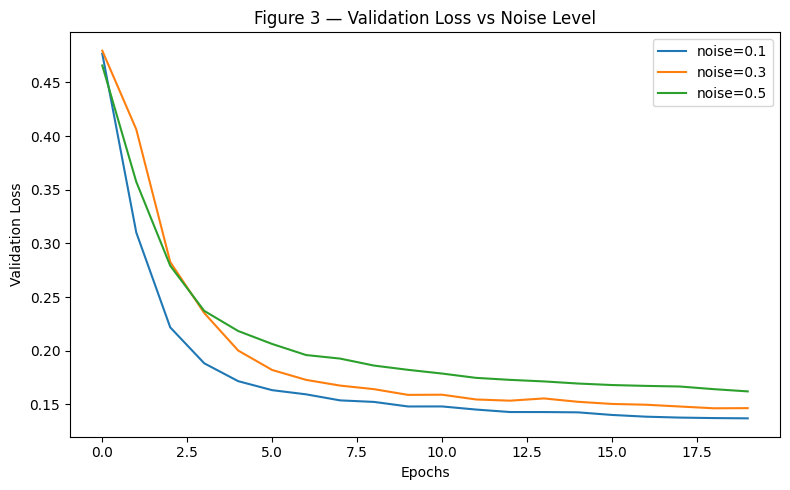

In [ ]:
#Experimaneting and fine tunning
# ── Experiment A: effect of noise level ───────────────────────────────────
results = {}

for noise in [0.1, 0.3, 0.5]:
    # Generate a freshly noised dataset at this level
    x_tr_n = add_gaussian_noise(x_train, noise)
    x_vl_n = add_gaussian_noise(x_val,   noise)

    # Build a fresh model (reset weights)
    model = build_autoencoder()

    h = model.fit(
        x_tr_n, x_train,
        epochs=20,
        batch_size=128,
        shuffle=True,
        validation_data=(x_vl_n, x_val),
        verbose=0   # silent training for cleaner output
    )

    final_val_loss = h.history['val_loss'][-1]
    results[f'noise={noise}'] = h.history['val_loss']
    print(f'Noise factor {noise}: final val_loss = {final_val_loss:.5f}')

# Plot all noise-level curves together
plt.figure(figsize=(8, 5))
for label, vals in results.items():
    plt.plot(vals, label=label)
plt.title('Figure 3 — Validation Loss vs Noise Level')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()
# Higher noise → harder task → higher final loss.

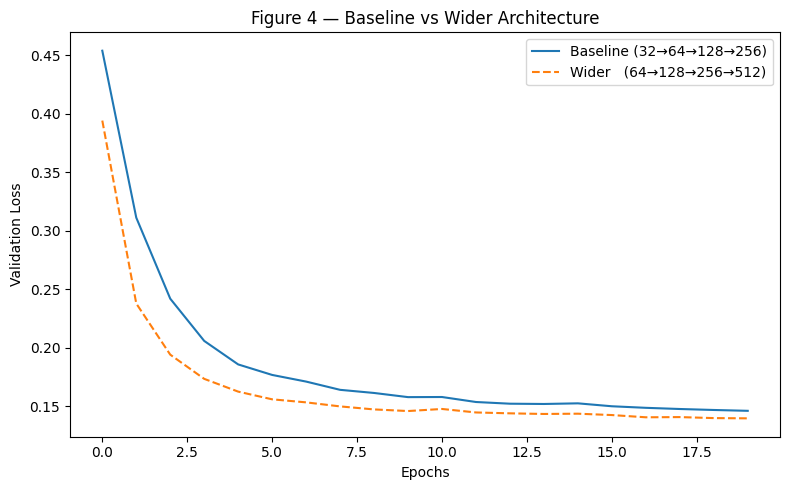

Baseline final val_loss: 0.146
Wider    final val_loss: 0.13957


In [ ]:
# ── Experiment B: wider filters ────────────────────────────────────────────
def build_wider_autoencoder(input_shape=(32, 32, 1)):
    """
    Same architecture but with more filters per layer:
    64 → 128 → 256 → 512  (vs 32 → 64 → 128 → 256 baseline)
    More filters = more capacity to model complex strokes,
    but also more parameters and longer training time.
    """
    inputs = keras.Input(shape=input_shape)

    # Encoder
    x = layers.Conv2D(64,  (3,3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2,2), padding='same')(x)
    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2,2), padding='same')(x)
    x = layers.Conv2D(256, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2,2), padding='same')(x)
    x = layers.Conv2D(512, (3,3), activation='relu', padding='same')(x)  # bottleneck

    # Decoder
    x = layers.Conv2DTranspose(256, (3,3), strides=(2,2), activation='relu', padding='same')(x)
    x = layers.Conv2DTranspose(128, (3,3), strides=(2,2), activation='relu', padding='same')(x)
    x = layers.Conv2DTranspose(64,  (3,3), strides=(2,2), activation='relu', padding='same')(x)
    out = layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

    model = Model(inputs, out, name='wider_autoencoder')
    model.compile(optimizer='adam', loss='binary_crossentropy')
    return model


# Train both baseline and wider model for 20 epochs and compare
NOISE = 0.3
x_tr_n = add_gaussian_noise(x_train, NOISE)
x_vl_n = add_gaussian_noise(x_val,   NOISE)

baseline_model = build_autoencoder()
h_base = baseline_model.fit(
    x_tr_n, x_train, epochs=20, batch_size=128,
    validation_data=(x_vl_n, x_val), shuffle=True, verbose=0
)

wider_model = build_wider_autoencoder()
h_wide = wider_model.fit(
    x_tr_n, x_train, epochs=20, batch_size=128,
    validation_data=(x_vl_n, x_val), shuffle=True, verbose=0
)

plt.figure(figsize=(8, 5))
plt.plot(h_base.history['val_loss'], label='Baseline (32→64→128→256)')
plt.plot(h_wide.history['val_loss'], label='Wider   (64→128→256→512)', linestyle='--')
plt.title('Figure 4 — Baseline vs Wider Architecture')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()
print('Baseline final val_loss:', round(h_base.history["val_loss"][-1], 5))
print('Wider    final val_loss:', round(h_wide.history["val_loss"][-1], 5))

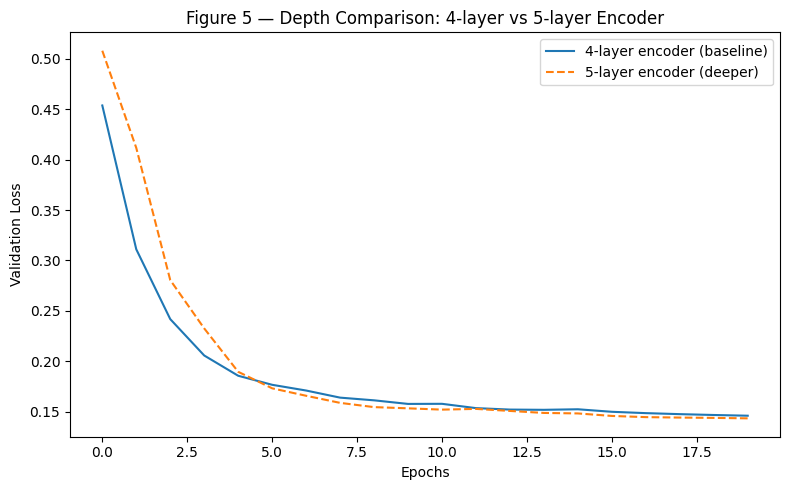

4-layer final val_loss: 0.146
5-layer final val_loss: 0.14339


In [ ]:
# ── Experiment C: 5-layer (deeper) encoder ────────────────────────────────
import keras.layers as layers
from keras.models import Model
def build_deeper_autoencoder(input_shape=(32, 32, 1)):
    """
    5 encoder conv blocks (no extra pooling after layer 4/5 to avoid
    reducing spatial dims below 2×2 for a 32-px image).
    Extra depth adds more non-linear transformations, helping the model
    learn more abstract character structure.
    """
    inputs = keras.Input(shape=input_shape)

    # Encoder
    x = layers.Conv2D(32,  (3,3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2,2), padding='same')(x)          # 16×16
    x = layers.Conv2D(64,  (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2,2), padding='same')(x)          # 8×8
    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2,2), padding='same')(x)          # 4×4
    x = layers.Conv2D(256, (3,3), activation='relu', padding='same')(x)  # 4×4
    x = layers.Conv2D(256, (3,3), activation='relu', padding='same')(x)  # 4×4 (extra depth)

    # Decoder
    x = layers.Conv2DTranspose(256, (3,3), strides=(2,2), activation='relu', padding='same')(x)
    x = layers.Conv2DTranspose(128, (3,3), strides=(2,2), activation='relu', padding='same')(x)
    x = layers.Conv2DTranspose(64,  (3,3), strides=(2,2), activation='relu', padding='same')(x)
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
    out = layers.Conv2D(1,  (3,3), activation='sigmoid', padding='same')(x)

    model = Model(inputs, out, name='deeper_autoencoder')
    model.compile(optimizer='adam', loss='binary_crossentropy')
    return model

deeper_model = build_deeper_autoencoder()
h_deep = deeper_model.fit(
    x_tr_n, x_train, epochs=20, batch_size=128,
    validation_data=(x_vl_n, x_val), shuffle=True, verbose=0
)

plt.figure(figsize=(8, 5))
plt.plot(h_base.history['val_loss'], label='4-layer encoder (baseline)')
plt.plot(h_deep.history['val_loss'], label='5-layer encoder (deeper)', linestyle='--')
plt.title('Figure 5 — Depth Comparison: 4-layer vs 5-layer Encoder')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()
print('4-layer final val_loss:', round(h_base.history["val_loss"][-1], 5))
print('5-layer final val_loss:', round(h_deep.history["val_loss"][-1], 5))